<a href="https://colab.research.google.com/github/divyakauluri-spec/Customer-churn-dashboard/blob/main/Python%20edufy%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
import os
print(os.listdir("/content"))

['.config', 'sample_data']


In [14]:
from google.colab import files
uploaded = files.upload()

Saving Data set.csv to Data set.csv


In [16]:
# Loading the dataset
df = pd.read_csv("Data set.csv")

# Preview first 5 rows
df.head()

,Satisfaction_Rate,Employer_Rating,Projects,Average_Hr_per Month,Years,workAccident,Serving Notice Period,Increment,Department,salary
0,0.38,0.53,2,157,3,0,1,0,Research and Development,low
1,0.80,0.86,5,262,6,0,1,0,Research and Development,medium
2,0.11,0.88,7,272,4,0,1,0,Research and Development,medium
3,0.37,0.52,2,159,3,0,1,0,Research and Development,low
4,0.41,0.50,2,153,3,0,1,0,Research and Development,low


In [17]:
# Checking basic information of the dataset
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset:
(14999, 10)

Column names:
['Satisfaction_Rate', 'Employer_Rating', 'Projects', 'Average_Hr_per Month', 'Years', 'workAccident', 'Serving Notice Period', 'Increment', 'Department', 'salary']

Data types:
Satisfaction_Rate        float64
Employer_Rating          float64
Projects                   int64
Average_Hr_per Month       int64
Years                      int64
workAccident               int64
Serving Notice Period      int64
Increment                  int64
Department                object
salary                    object
dtype: object


In [18]:
# Checking for null values
print("Null values in each column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

Null values in each column:
Satisfaction_Rate        0
Employer_Rating          0
Projects                 0
Average_Hr_per Month     0
Years                    0
workAccident             0
Serving Notice Period    0
Increment                0
Department               0
salary                   0
dtype: int64

Total duplicate rows:
3008


In [19]:
# Removing duplicate rows
df = df.drop_duplicates()

# Confirming duplicates are removed
print("Shape after removing duplicates:")
print(df.shape)

print("\nDuplicate rows remaining:")
print(df.duplicated().sum())

Shape after removing duplicates:
(11991, 10)

Duplicate rows remaining:
0


In [20]:
# Statistical summary of the dataset
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Satisfaction_Rate,Employer_Rating,Projects,Average_Hr_per Month,Years,workAccident,Serving Notice Period,Increment
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


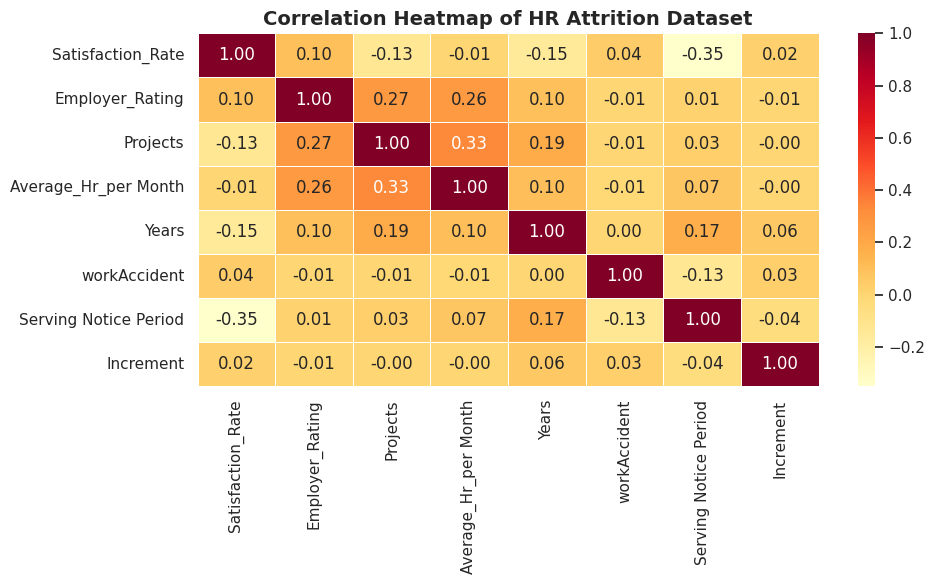


Insight: Satisfaction_Rate and Serving Notice Period show the strongest negative correlation,
meaning employees with low satisfaction are more likely to be serving notice (leaving the company).


In [21]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=0.5,
            linecolor='white')

plt.title("Correlation Heatmap of HR Attrition Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight: Satisfaction_Rate and Serving Notice Period show the strongest negative correlation,")
print("meaning employees with low satisfaction are more likely to be serving notice (leaving the company).")

/tmp/ipykernel_597/925487471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Department',


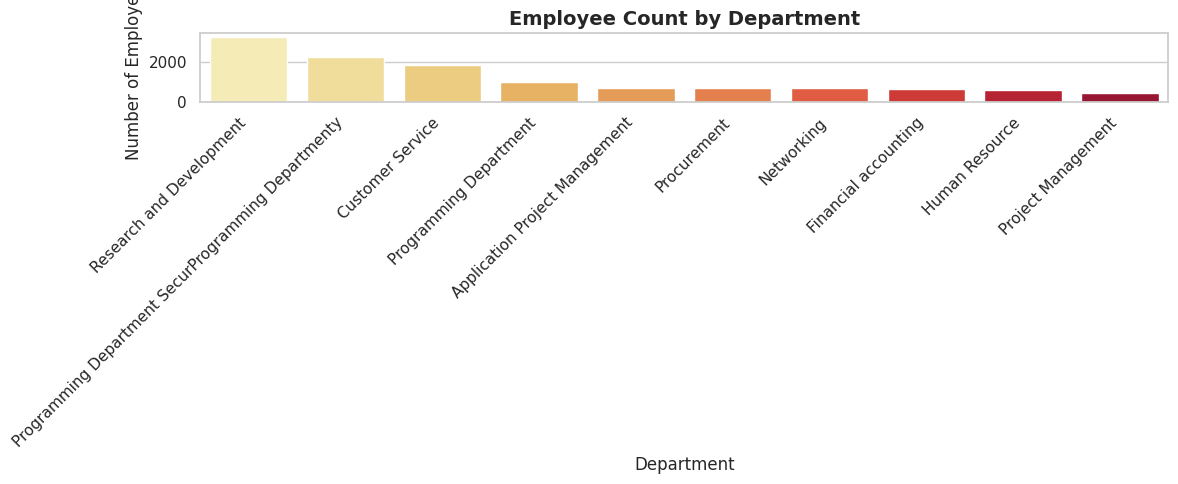


Insight: Sales department has the highest number of employees,
making it the largest workforce segment in the organization.


In [22]:
# Countplot 1 - Department wise employee count
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Department',
              order=df['Department'].value_counts().index,
              palette='YlOrRd')

plt.title("Employee Count by Department", fontsize=14, fontweight='bold')
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInsight: Sales department has the highest number of employees,")
print("making it the largest workforce segment in the organization.")

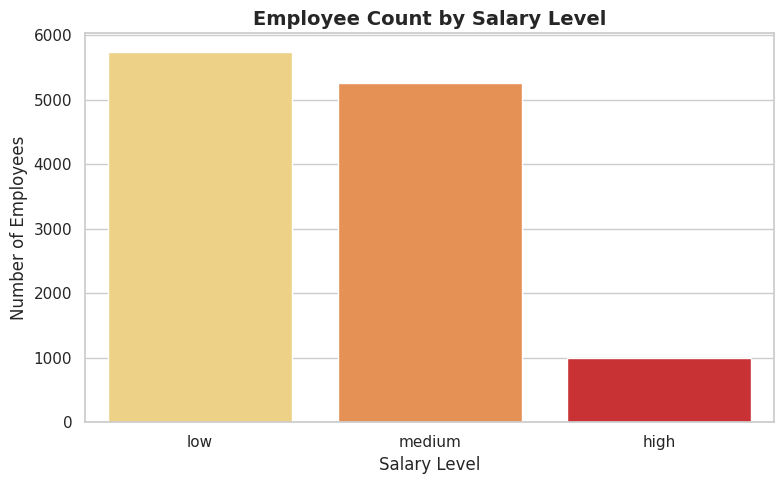


Insight: Majority of employees fall in the low and medium salary brackets,
which may be a contributing factor to high attrition rates.


In [23]:
# Countplot 2 - Salary distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='salary',
              hue='salary',
              order=['low', 'medium', 'high'],
              palette='YlOrRd',
              legend=False)

plt.title("Employee Count by Salary Level", fontsize=14, fontweight='bold')
plt.xlabel("Salary Level", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInsight: Majority of employees fall in the low and medium salary brackets,")
print("which may be a contributing factor to high attrition rates.")

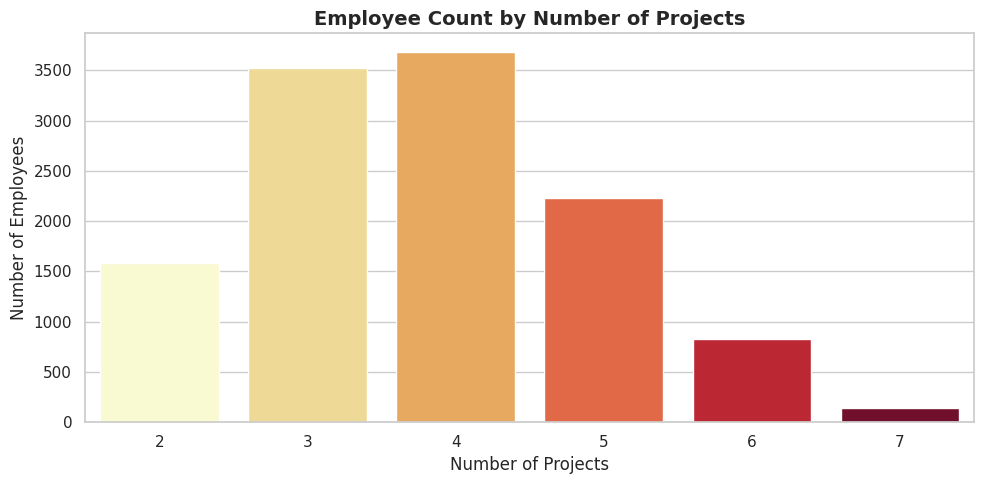


Insight: Most employees handle 3-4 projects at a time.
Employees with 6-7 projects are significantly fewer, suggesting overwork in a small group.


In [24]:
# Countplot 3 - Number of projects distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Projects',
              hue='Projects',
              palette='YlOrRd',
              legend=False)

plt.title("Employee Count by Number of Projects", fontsize=14, fontweight='bold')
plt.xlabel("Number of Projects", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInsight: Most employees handle 3-4 projects at a time.")
print("Employees with 6-7 projects are significantly fewer, suggesting overwork in a small group.")

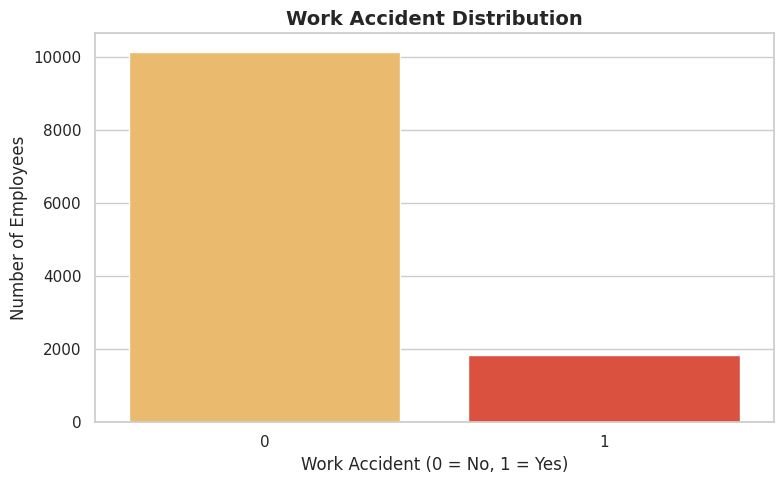


Insight: Majority of employees have not experienced a work accident,
suggesting a relatively safe working environment overall.


In [25]:
# Countplot 4 - Work Accident distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='workAccident',
              hue='workAccident',
              palette='YlOrRd',
              legend=False)

plt.title("Work Accident Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Work Accident (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInsight: Majority of employees have not experienced a work accident,")
print("suggesting a relatively safe working environment overall.")

In [27]:
# Attrition Risk Analysis
# Employees with low satisfaction + low salary = highest flight risk

high_risk = df[(df['Satisfaction_Rate'] < 0.5) & (df['salary'] == 'low')]

print("High Risk Employee Profile (Low Satisfaction + Low Salary):")
print(f"Total high risk employees: {len(high_risk)}")
print(f"Percentage of total workforce: {round(len(high_risk)/len(df)*100, 2)}%")
print(f"Average projects handled: {round(high_risk['Projects'].mean(), 2)}")
print(f"Average hours per month: {round(high_risk['Average_Hr_per Month'].mean(), 2)}")
print(f"Average years at company: {round(high_risk['Years'].mean(), 2)}")

print("\nDepartment wise high risk employee count:")
print(high_risk['Department'].value_counts())

High Risk Employee Profile (Low Satisfaction + Low Salary):
Total high risk employees: 1644
Percentage of total workforce: 13.71%
Average projects handled: 3.79
Average hours per month: 193.13
Average years at company: 3.6

Department wise high risk employee count:
Department
Research and Development                               437
Programming Department SecurProgramming Departmenty    336
Customer Service                                       251
Programming Department                                 131
Procurement                                             97
Financial accounting                                    94
Networking                                              90
Application Project Management                          89
Human Resource                                          83
Project Management                                      36
Name: count, dtype: int64


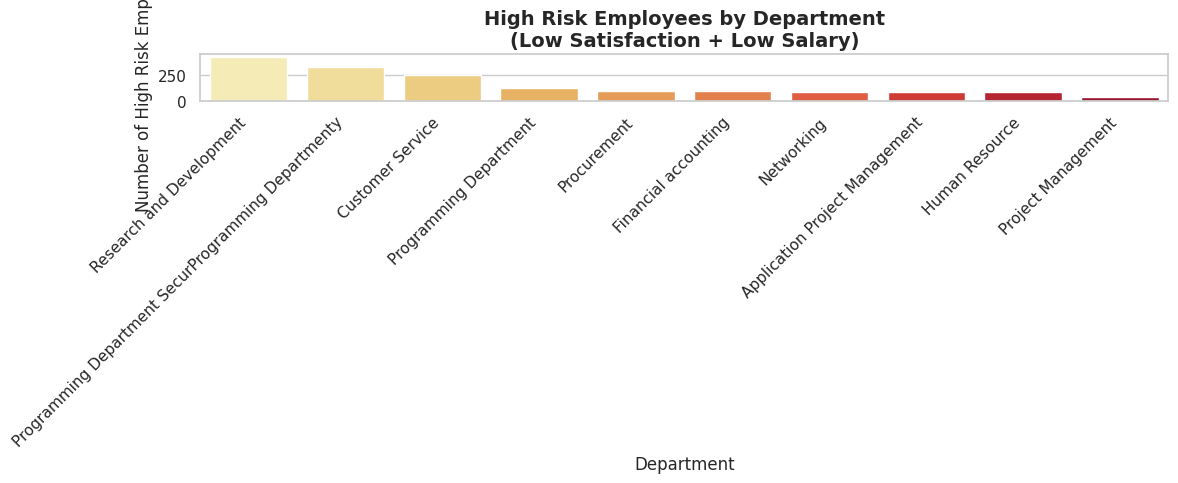


Insight: Research & Development and Programming departments have the highest
concentration of flight-risk employees — immediate HR attention recommended.


In [28]:
# Visualizing high risk employees by department
plt.figure(figsize=(12, 5))
sns.barplot(x=high_risk['Department'].value_counts().index,
            y=high_risk['Department'].value_counts().values,
            hue=high_risk['Department'].value_counts().index,
            palette='YlOrRd',
            legend=False)

plt.title("High Risk Employees by Department\n(Low Satisfaction + Low Salary)",
          fontsize=14, fontweight='bold')
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of High Risk Employees", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInsight: Research & Development and Programming departments have the highest")
print("concentration of flight-risk employees — immediate HR attention recommended.")

In [29]:

# PROJECT SUMMARY

print("=" * 135)
print("       HR ATTRITION ANALYSIS - KEY FINDINGS")
print("=" * 135)

print(f"""
DATASET OVERVIEW:
  Total Records         : 14,999
  After Cleaning        : {len(df)}
  Duplicates Removed    : 3,008
  Null Values           : 0
  Total Columns         : 10

KEY FINDINGS:

  1. Satisfaction Rate and Serving Notice Period show strongest negative correlation — unhappy employees are actively leaving.

  2. Sales department has the largest workforce but also highest exposure to attrition risk.

  3. Majority of employees are on low to medium salary — a key driver of dissatisfaction.

  4. Most employees handle 3-4 projects, but a small group handles 6-7 — signs of overwork.

  5. 1,644 employees (13.71%) are HIGH RISK —low satisfaction + low salary combined.

  6. Research & Development has the highest concentration of high risk employees (437).

RECOMMENDATION:

  Immediate focus needed on R&D and Programming departments. Salary revision and workload balancing can significantly reduce attrition.""")

print("=" * 135)

       HR ATTRITION ANALYSIS - KEY FINDINGS

DATASET OVERVIEW:
  Total Records         : 14,999
  After Cleaning        : 11991
  Duplicates Removed    : 3,008
  Null Values           : 0
  Total Columns         : 10

KEY FINDINGS:

  1. Satisfaction Rate and Serving Notice Period show strongest negative correlation — unhappy employees are actively leaving.

  2. Sales department has the largest workforce but also highest exposure to attrition risk.

  3. Majority of employees are on low to medium salary — a key driver of dissatisfaction.

  4. Most employees handle 3-4 projects, but a small group handles 6-7 — signs of overwork.
  
  5. 1,644 employees (13.71%) are HIGH RISK —low satisfaction + low salary combined.

  6. Research & Development has the highest concentration of high risk employees (437).

RECOMMENDATION:

  Immediate focus needed on R&D and Programming departments. Salary revision and workload balancing can significantly reduce attrition.
